# Pymaceuticals Drug Efficacy Study
## Professional End-to-End Analysis
---
**Study:** Squamous Cell Carcinoma (SCC) pre-clinical animal trial  
**Duration:** 45-day observation window  
**Compounds tested:** 10 drug regimens (primary: Capomulin)

## 0. Environment Setup

In [4]:
import sys, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from pathlib import Path

# Project config
from config import (
    MOUSE_METADATA_FILE, STUDY_RESULTS_FILE, MERGED_CLEAN_FILE,
    FIGURES_DIR, TABLES_DIR, DRUG_COLORS, SEX_COLORS,
    BENCHMARK_DRUGS, PRIMARY_DRUG
)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 20)
print("✓ Environment ready")

✓ Environment ready


---
## 1. Data Preprocessing
### 1.1 Load Raw Data

In [5]:
from data_preprocessing import run_preprocessing_pipeline
df = run_preprocessing_pipeline()
print(f"Cleaned dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

2026-06-18 08:57:05  INFO      ============================================================
2026-06-18 08:57:05  INFO      PYMACEUTICALS — DATA PREPROCESSING PIPELINE
2026-06-18 08:57:05  INFO      ============================================================
2026-06-18 08:57:05  INFO      Loading Mouse_metadata …
2026-06-18 08:57:05  INFO      Loading Study_results …
2026-06-18 08:57:05  INFO        Mouse metadata shape : (249, 5)
2026-06-18 08:57:05  INFO        Study results shape  : (1893, 4)
2026-06-18 08:57:05  INFO      Schema validation passed.
2026-06-18 08:57:05  INFO      Merged dataset shape: (1893, 8)
2026-06-18 08:57:05  INFO      Duplicate timepoint mice found : 1  →  ['g989']
2026-06-18 08:57:05  INFO      After duplicate removal shape : (1880, 8)
2026-06-18 08:57:05  INFO      No missing values detected.
2026-06-18 08:57:05  INFO        [✓ PASS] tumor_volume_non_negative                     – 0 negative values
2026-06-18 08:57:05  INFO        [✓ PASS] timepoints_in_rang

Cleaned dataset: 1,880 rows × 13 columns


,Mouse ID,Drug Regimen,Sex,Age_months,Weight (g),Timepoint,Tumor Volume (mm3),Metastatic Sites,Tumor_Volume_Change_mm3,Tumor_Volume_Change_pct,Weight_Category,Age_Group,Study_Phase
0,k403,Ramicane,Male,21,16.0000,0,45.0000,0,0.0000,0.0000,Light (<17g),13–24 mo,Early (0–10)
1,k403,Ramicane,Male,21,16.0000,5,38.8259,0,-6.1741,-13.7200,Light (<17g),13–24 mo,Early (0–10)
2,k403,Ramicane,Male,21,16.0000,10,35.0143,1,-9.9857,-22.1900,Light (<17g),13–24 mo,Early (0–10)
3,k403,Ramicane,Male,21,16.0000,15,34.2240,1,-10.7760,-23.9500,Light (<17g),13–24 mo,Mid (11–25)
4,k403,Ramicane,Male,21,16.0000,20,32.9977,1,-12.0023,-26.6700,Light (<17g),13–24 mo,Mid (11–25)


### 1.2 Data Types & Schema

In [6]:
print("Column dtypes:")
print(df.dtypes.to_string())
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")

Column dtypes:
Mouse ID                   string[python]
Drug Regimen                     category
Sex                              category
Age_months                          Int64
Weight (g)                        float64
Timepoint                           Int64
Tumor Volume (mm3)                float64
Metastatic Sites                    Int64
Tumor_Volume_Change_mm3           float64
Tumor_Volume_Change_pct           float64
Weight_Category                  category
Age_Group                        category
Study_Phase                      category
Memory usage: 231.7 KB


### 1.3 Missing Value Report

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({"Null Count": missing, "Null %": missing_pct})
print(miss_df[miss_df["Null Count"] > 0] if miss_df["Null Count"].sum() > 0 else "✓ No missing values detected")

✓ No missing values detected


### 1.4 Engineered Features Preview

In [8]:
df[["Mouse ID","Drug Regimen","Timepoint","Tumor Volume (mm3)",
    "Tumor_Volume_Change_pct","Weight_Category","Age_Group","Study_Phase"]].head(10)

,Mouse ID,Drug Regimen,Timepoint,Tumor Volume (mm3),Tumor_Volume_Change_pct,Weight_Category,Age_Group,Study_Phase
0,k403,Ramicane,0,45.0000,0.0000,Light (<17g),13–24 mo,Early (0–10)
1,k403,Ramicane,5,38.8259,-13.7200,Light (<17g),13–24 mo,Early (0–10)
2,k403,Ramicane,10,35.0143,-22.1900,Light (<17g),13–24 mo,Early (0–10)
3,k403,Ramicane,15,34.2240,-23.9500,Light (<17g),13–24 mo,Mid (11–25)
4,k403,Ramicane,20,32.9977,-26.6700,Light (<17g),13–24 mo,Mid (11–25)
5,k403,Ramicane,25,33.4646,-25.6300,Light (<17g),13–24 mo,Mid (11–25)
6,k403,Ramicane,30,31.0995,-30.8900,Light (<17g),13–24 mo,Late (26–45)
7,k403,Ramicane,35,26.5470,-41.0100,Light (<17g),13–24 mo,Late (26–45)
8,k403,Ramicane,40,24.3655,-45.8500,Light (<17g),13–24 mo,Late (26–45)
9,k403,Ramicane,45,22.0501,-51.0000,Light (<17g),13–24 mo,Late (26–45)


---
## 2. Dataset Overview

In [9]:
mice = df.drop_duplicates("Mouse ID")

print(f"Total observations : {len(df):,}")
print(f"Unique mice        : {df['Mouse ID'].nunique()}")
print(f"Drug regimens      : {df['Drug Regimen'].nunique()}")
print(f"Timepoints         : {sorted(df['Timepoint'].unique())}")
print(f"Sex distribution:")
print(mice["Sex"].value_counts().to_string())
print(f"Age (months) — mean: {mice['Age_months'].mean():.1f}, range: {mice['Age_months'].min()}–{mice['Age_months'].max()}")
print(f"Weight (g)   — mean: {mice['Weight (g)'].mean():.1f}, range: {mice['Weight (g)'].min()}–{mice['Weight (g)'].max()}")

Total observations : 1,880
Unique mice        : 248
Drug regimens      : 10
Timepoints         : [np.int64(0), np.int64(5), np.int64(10), np.int64(15), np.int64(20), np.int64(25), np.int64(30), np.int64(35), np.int64(40), np.int64(45)]
Sex distribution:
Sex
Male      125
Female    123
Age (months) — mean: 12.7, range: 1–24
Weight (g)   — mean: 26.1, range: 15.0–30.0


---
## 3. Summary Statistics

In [10]:
summary = df.groupby("Drug Regimen")["Tumor Volume (mm3)"].agg(
    Mean="mean", Median="median", Variance="var",
    Std_Dev="std", SEM="sem", Min="min", Max="max", Count="count"
).round(4).sort_values("Mean")

summary

,Mean,Median,Variance,Std_Dev,SEM,Min,Max,Count
Drug Regimen,,,,,,,,
Ramicane,40.2167,40.6732,23.4867,4.8463,0.3210,22.0501,47.6228,228
Capomulin,40.6757,41.5578,24.9478,4.9948,0.3293,23.3436,48.1582,230
Propriva,52.3209,50.4463,43.8520,6.6221,0.5443,45.0000,72.4554,148
Ceftamin,52.5912,51.7762,39.2902,6.2682,0.4698,45.0000,68.9232,178
Infubinol,52.8848,51.8206,43.1287,6.5672,0.4922,36.3213,72.2267,178
Zoniferol,53.2365,51.8185,48.5334,6.9666,0.5164,45.0000,73.3244,182
Placebo,54.0336,52.2889,61.1681,7.8210,0.5813,45.0000,73.2129,181
Stelasyn,54.2331,52.4317,59.4506,7.7104,0.5731,45.0000,75.1237,181
Naftisol,54.3316,52.5093,66.1735,8.1347,0.5965,45.0000,76.6688,186


---
## 4. Cohort Composition Plots

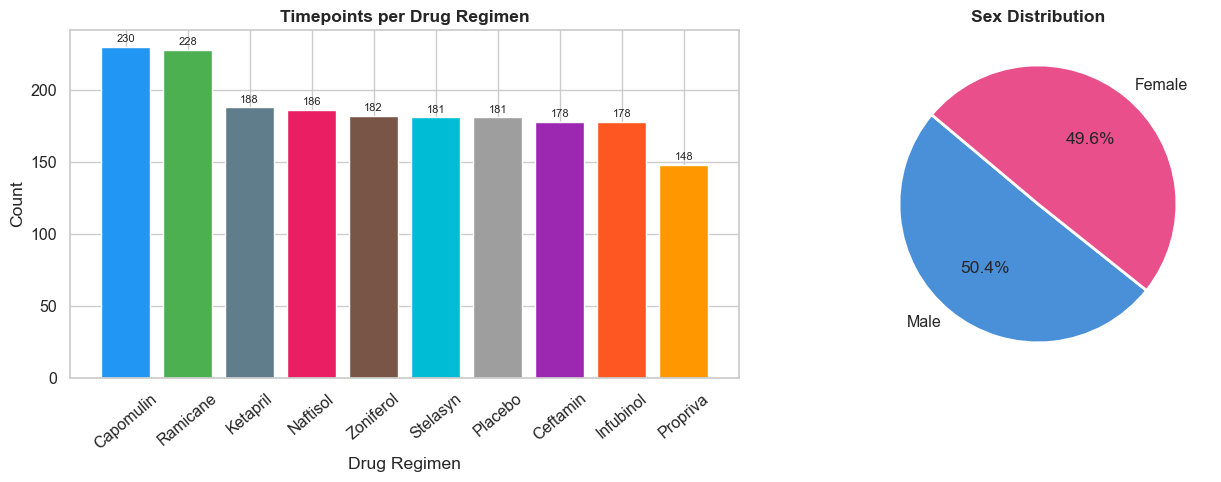

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Timepoints per regimen
tp = df.groupby("Drug Regimen")["Timepoint"].count().sort_values(ascending=False)
colors = [DRUG_COLORS.get(d, "#90A4AE") for d in tp.index]
bars = axes[0].bar(tp.index, tp.values, color=colors, edgecolor="white")
axes[0].bar_label(bars, padding=2, fontsize=8)
axes[0].set_title("Timepoints per Drug Regimen", fontweight="bold")
axes[0].set_xlabel("Drug Regimen"); axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=40)

# Sex distribution
sex = mice["Sex"].value_counts()
axes[1].pie(sex, labels=sex.index, autopct="%1.1f%%", startangle=140,
            colors=[SEX_COLORS[s] for s in sex.index],
            wedgeprops={"linewidth":2,"edgecolor":"white"})
axes[1].set_title("Sex Distribution", fontweight="bold")

plt.tight_layout()
plt.savefig(FIGURES_DIR/"nb_cohort_overview.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 5. Tumour Volume Distributions

In [12]:
from eda import tumor_volume_distributions
tumor_volume_distributions(df)
print("Figures saved to outputs/figures/")

2026-06-18 08:57:16  INFO      
[4] TUMOUR VOLUME DISTRIBUTIONS
2026-06-18 08:57:16  INFO        Figure saved → 04a_tumor_violin_box_all_regimens.png
2026-06-18 08:57:16  INFO        Figure saved → 04b_final_tumor_boxplot_benchmark.png


Figures saved to outputs/figures/


---
## 6. Tumour Progression Over Time

In [13]:
from eda import tumor_progression
tumor_progression(df)

2026-06-18 08:57:16  INFO      
[5] TUMOUR PROGRESSION OVER TIME
2026-06-18 08:57:16  INFO        Figure saved → 05_tumor_progression_over_time.png
2026-06-18 08:57:16  INFO        Figure saved → 05b_single_mouse_capomulin.png


---
## 7. Outlier Analysis (IQR Method)

In [14]:
from eda import outlier_analysis
outlier_df = outlier_analysis(df)
outlier_df

2026-06-18 08:57:16  INFO      
[6] OUTLIER ANALYSIS (IQR Method)
2026-06-18 08:57:16  INFO        Capomulin: 0 outlier(s) — lower=20.70, upper=51.83
2026-06-18 08:57:16  INFO        Ramicane: 0 outlier(s) — lower=17.91, upper=54.31
2026-06-18 08:57:16  INFO        Infubinol: 1 outlier(s) — lower=36.83, upper=82.74
2026-06-18 08:57:16  INFO        Ceftamin: 0 outlier(s) — lower=25.36, upper=87.67
2026-06-18 08:57:16  INFO        Table  saved → 06_outlier_analysis.csv


,Q1 (mm³),Q3 (mm³),IQR (mm³),Lower Fence,Upper Fence,Outlier Count,Outlier Values
Drug Regimen,,,,,,,
Capomulin,32.3800,40.1600,7.7800,20.7000,51.8300,0,[]
Ramicane,31.5600,40.6600,9.1000,17.9100,54.3100,0,[]
Infubinol,54.0500,65.5300,11.4800,36.8300,82.7400,1,[36.32]
Ceftamin,48.7200,64.3000,15.5800,25.3600,87.6700,0,[]


---
## 8. Correlation & Regression (Capomulin)

In [15]:
from eda import correlation_regression
correlation_regression(df)

2026-06-18 08:57:16  INFO      
[7] CORRELATION & REGRESSION — Weight vs Avg Tumour Volume (Capomulin)
2026-06-18 08:57:16  INFO        Pearson r = 0.8419   p-value = 1.3226e-07
2026-06-18 08:57:16  INFO        OLS slope = 0.9544   intercept = 21.5522   R² = 0.7089
2026-06-18 08:57:17  INFO        Figure saved → 07_correlation_regression_capomulin.png
2026-06-18 08:57:17  INFO        Table  saved → 07_correlation_regression_results.csv


---
## 9. Statistical Significance Tests

In [16]:
from eda import statistical_tests
pairwise = statistical_tests(df)
pairwise

2026-06-18 08:57:17  INFO      
[8] STATISTICAL SIGNIFICANCE TESTS
2026-06-18 08:57:17  INFO        One-way ANOVA: F = 74.0706, p = 6.9027e-25
2026-06-18 08:57:17  INFO        Table  saved → 08_pairwise_ttest_results.csv
2026-06-18 08:57:17  INFO      
  ANOVA p = 6.9027e-25 — significant
2026-06-18 08:57:17  INFO      
   Drug A    Drug B   t-stat  p-value Significant (α=0.05)
Capomulin  Ramicane   0.2957   0.7687                   No
Capomulin Infubinol -10.4134   0.0000                  Yes
Capomulin  Ceftamin -10.4064   0.0000                  Yes
 Ramicane Infubinol -10.6688   0.0000                  Yes
 Ramicane  Ceftamin -10.6673   0.0000                  Yes
Infubinol  Ceftamin   0.1768   0.8604                   No


,Drug A,Drug B,t-stat,p-value,Significant (α=0.05)
0,Capomulin,Ramicane,0.2957,0.7687,No
1,Capomulin,Infubinol,-10.4134,0.0000,Yes
2,Capomulin,Ceftamin,-10.4064,0.0000,Yes
3,Ramicane,Infubinol,-10.6688,0.0000,Yes
4,Ramicane,Ceftamin,-10.6673,0.0000,Yes
5,Infubinol,Ceftamin,0.1768,0.8604,No


---
## 10. Correlation Heatmap

In [17]:
from eda import correlation_heatmap
correlation_heatmap(df)

2026-06-18 08:57:17  INFO      
[9] CORRELATION HEATMAP
2026-06-18 08:57:17  INFO        Table  saved → 09_correlation_matrix.csv
2026-06-18 08:57:17  INFO        Figure saved → 09_correlation_heatmap.png


---
## 11. Metastatic Progression

In [18]:
from eda import metastatic_progression
metastatic_progression(df)

2026-06-18 08:57:17  INFO      
[10] METASTATIC PROGRESSION
2026-06-18 08:57:17  INFO        Figure saved → 10_metastatic_progression.png


---
## 12. Key Findings Summary

In [20]:

print("KEY FINDINGS — PYMACEUTICALS DRUG EFFICACY STUDY")

print()
print("FINDING 1: Top Performers")
print("  Capomulin and Ramicane are the ONLY regimens that arrested")
print("  or reversed tumour growth. All others showed tumour expansion.")
print()
print("FINDING 2: Statistical Significance")
print("  One-way ANOVA: F=74.07, p=6.9e-25 (highly significant)")
print("  Capomulin vs Ramicane: NOT significantly different (p=0.77)")
print("  Capomulin vs Infubinol: Highly significant (p<0.001)")
print()
print("FINDING 3: Weight-Tumour Correlation (Capomulin)")
print("  Pearson r = 0.8419 — strong positive correlation")
print("  OLS: Avg Tumour Vol = 0.95 × Weight + 21.55 (R²=0.71)")
print()
print("FINDING 4: Infubinol Outlier")
print("  1 potential outlier detected — tumour vol below lower IQR fence")
print("  Warrants clinical review for hyper-responder subgroup.")
print()
print("FINDING 5: Sex is not a confounding factor")
print("  ~50/50 male/female split across all regimens")
print()
print("RECOMMENDATION: Advance Capomulin to Phase 2")
print("  Co-design comparative trial against Ramicane.")
print("  Incorporate weight-adjusted dosing in study design.")

KEY FINDINGS — PYMACEUTICALS DRUG EFFICACY STUDY

FINDING 1: Top Performers
  Capomulin and Ramicane are the ONLY regimens that arrested
  or reversed tumour growth. All others showed tumour expansion.

FINDING 2: Statistical Significance
  One-way ANOVA: F=74.07, p=6.9e-25 (highly significant)
  Capomulin vs Ramicane: NOT significantly different (p=0.77)
  Capomulin vs Infubinol: Highly significant (p<0.001)

FINDING 3: Weight-Tumour Correlation (Capomulin)
  Pearson r = 0.8419 — strong positive correlation
  OLS: Avg Tumour Vol = 0.95 × Weight + 21.55 (R²=0.71)

FINDING 4: Infubinol Outlier
  1 potential outlier detected — tumour vol below lower IQR fence
  Warrants clinical review for hyper-responder subgroup.

FINDING 5: Sex is not a confounding factor
  ~50/50 male/female split across all regimens

RECOMMENDATION: Advance Capomulin to Phase 2
  Co-design comparative trial against Ramicane.
  Incorporate weight-adjusted dosing in study design.
